1: n = 1000
2: n = 1000
3: n = 1000
4: n = 1000
5: n = 1000
6: n = 1000
7: n = 1000
8: n = 1000
9: n = 1000
10: n = 1000
11: n = 1000
12: n = 1000
13: n = 1000
14: n = 1000
15: n = 1000
16: n = 1000
17: n = 1000
18: n = 1000
19: n = 1000
20: n = 1000
21: n = 1000


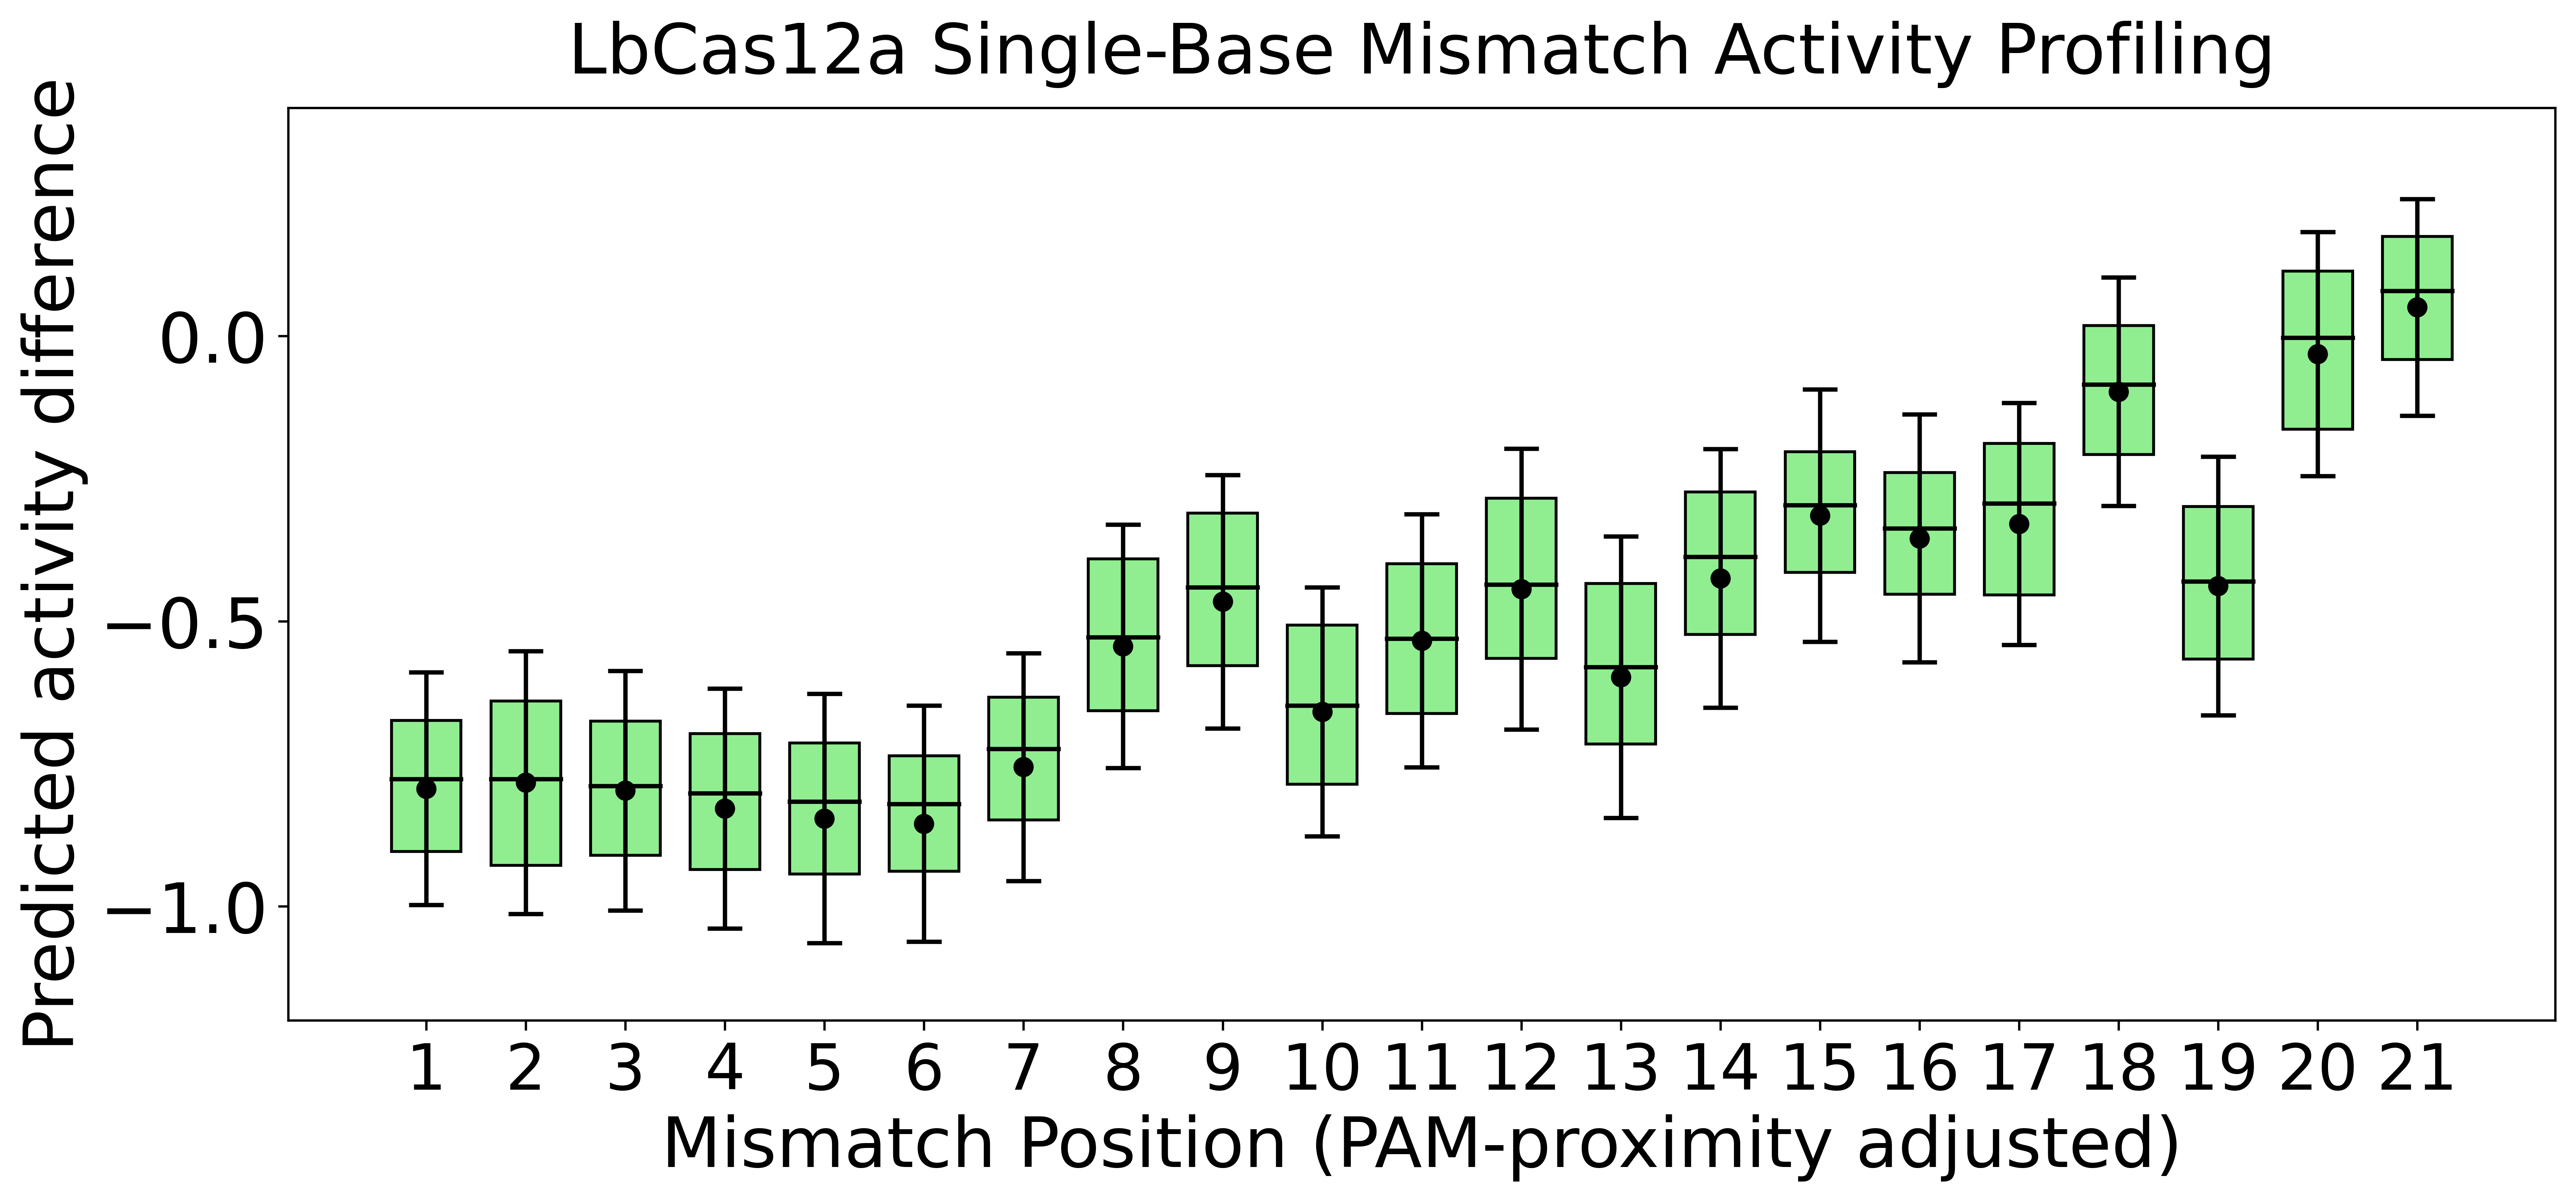

In [3]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# === Update font sizes globally ===
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 24,
    'xtick.labelsize': 22,
    'ytick.labelsize': 24,
    'legend.fontsize': 14
})

sample_counts = []

folder = '.'  # adjust if needed

# Build the expected file list in numeric order 1..21
def fname_for_pos(pos):
    return f"test_generated_random_dna_mismatch_single_{pos}_diff_avg.txt"

file_list = []
positions = []
for pos in range(1, 22):  # 1..21 inclusive
    fp = os.path.join(folder, fname_for_pos(pos))
    if os.path.isfile(fp):
        file_list.append(fp)
        positions.append(pos)
    else:
        # if missing, still reserve the slot but mark as missing
        file_list.append(None)
        positions.append(pos)

# Collect stats
q1_values, q3_values = [], []
medians, means, stds = [], [], []
valid_positions = []  # positions that actually had data

for fp, pos in zip(file_list, positions):
    if fp is None:
        continue
    with open(fp, 'r') as f:
        values = [float(line.strip()) for line in f if line.strip()]
    if not values:
        continue

    values = np.array(values, dtype=float)
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)
    median = np.median(values)
    mean = np.mean(values)
    std = np.std(values, ddof=0)

    q1_values.append(q1)
    q3_values.append(q3)
    medians.append(median)
    means.append(mean)
    stds.append(std)
    valid_positions.append(pos)
    sample_counts.append(len(values))

# Plot (only for positions with data)
x = np.arange(len(valid_positions))
fig, ax = plt.subplots(figsize=(max(12, len(valid_positions) * 0.6), 6), dpi=600)
box_width = 0.7
error_bar_width = box_width * 0.5

ax.grid(False)

# Draw IQR boxes
for i, (q1, q3) in enumerate(zip(q1_values, q3_values)):
    height = q3 - q1
    # facecolor set; edgecolor black
    rect = patches.Rectangle((i - box_width/2, q1), box_width, height,
                             facecolor='lightgreen', edgecolor='black')
    ax.add_patch(rect)

# Draw median lines
for i, med in enumerate(medians):
    ax.plot([i - box_width/2, i + box_width/2], [med, med], color='black', linewidth=1.5)

# Draw custom mean ± SD error bars
for i, (m, s) in enumerate(zip(means, stds)):
    ax.plot([i], [m], marker='o', color='black')  # Mean point
    ax.vlines(i, m - s, m + s, color='black', linewidth=1.5)
    ax.hlines([m - s, m + s], i - error_bar_width/2, i + error_bar_width/2,
              color='black', linewidth=1.5)

for lbl, n in zip(valid_positions, sample_counts):
    print(f"{lbl}: n = {n}")

# Axis styling
ax.set_xticks(x)
ax.set_xticklabels([str(p) for p in valid_positions], rotation=0, ha='center')
ax.set_xlabel("Mismatch Position (PAM-proximity adjusted)")
ax.set_ylabel("Predicted activity difference")
ax.set_title(
    "LbCas12a Single-Base Mismatch Activity Profiling",
    fontsize=24,
    pad=12
)


# Keep your y-limits if desired; adjust/remove if your values differ
ax.set_ylim(-1.2, 0.4)

plt.tight_layout()
plt.show()
